# 4 — Analysis and visualization (OECD ASD prevalence)

## Objective

This notebook performs the analytical exploration and visualization of ASD prevalence
across OECD countries using the metrics computed in previous steps.

Input datasets:

- outputs from `03_metrics_sex_age.ipynb`

Main steps:

1. Explore gender differences across age groups
2. Analyze temporal trends in ASD prevalence
3. Compare prevalence across countries
4. Compare prevalence across regions
5. Generate visualizations to support interpretation

## 4.1 — Environment and project setup

Prepare the notebook environment and project configuration.

Includes:

- core library imports  
- environment validation  
- project path setup  

In [73]:
# Import core libraries and visualization tools for analysis

import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt
import seaborn as sns

from src.paths import RAW_DIR, PROCESSED_DIR, ensure_data_dirs

In [74]:
# Validate environment configuration and library availability for analysis

print("Python version:", sys.version.split()[0])

try:
    import src
    print("Project package import: OK")
except ImportError:
    print("ERROR: project package 'src' not found")

print("pandas version:", pd.__version__)

Python version: 3.13.5
Project package import: OK
pandas version: 2.2.3


In [75]:
# Define output directory for figures

FIGURES_DIR = PROCESSED_DIR.parent / "reports/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Ensure project data directories exist and validate path configuration

ensure_data_dirs()

print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

RAW_DIR: C:\Users\samai\OneDrive\Escritorio\PROYECTO AUTISMO\autism-diagnosis-gender-gap\data\1_raw
PROCESSED_DIR: C:\Users\samai\OneDrive\Escritorio\PROYECTO AUTISMO\autism-diagnosis-gender-gap\data\3_processed


## 4.2 Data ingestion

Load analytical datasets generated in previous steps for visualization and interpretation.

Datasets:
- gender × age metrics
- gender × year trends
- country-level comparison
- regional comparison

In [76]:
# Load analytical datasets generated in previous notebook

df_gender_age_pivot = pd.read_csv(PROCESSED_DIR / "df_gender_age_pivot.csv")
df_gender_year_pivot = pd.read_csv(PROCESSED_DIR / "df_gender_year_pivot.csv")
df_country_gender_pivot = pd.read_csv(PROCESSED_DIR / "df_country_gender_pivot.csv")
df_region_gender_pivot = pd.read_csv(PROCESSED_DIR / "df_region_gender_pivot.csv")

# Inspect loaded datasets

print("Gender × age shape:", df_gender_age_pivot.shape)
display(df_gender_age_pivot.head())

print("\nGender × year shape:", df_gender_year_pivot.shape)
display(df_gender_year_pivot.head())

print("\nCountry × gender shape:", df_country_gender_pivot.shape)
display(df_country_gender_pivot.head())

print("\nRegion × gender shape:", df_region_gender_pivot.shape)
display(df_region_gender_pivot.head())

Gender × age shape: (15, 7)


,age_range,female_prevalence,male_prevalence,difference,ratio,female_pct,male_pct
0,<5,577.0,1512.0,935.0,2.62,0.58,1.51
1,5-9,537.0,1437.0,900.0,2.67,0.54,1.44
2,10-14,499.0,1371.0,872.0,2.75,0.50,1.37
3,15-19,465.0,1313.0,848.0,2.82,0.46,1.31
4,20-24,436.0,1264.0,829.0,2.90,0.44,1.26



Gender × year shape: (34, 7)


,year,female_prevalence,male_prevalence,difference,ratio,female_pct,male_pct
0,1990,337.0,1063.0,726.0,3.15,0.34,1.06
1,1991,339.0,1065.0,726.0,3.14,0.34,1.06
2,1992,340.0,1067.0,727.0,3.14,0.34,1.07
3,1993,342.0,1069.0,728.0,3.13,0.34,1.07
4,1994,343.0,1072.0,729.0,3.12,0.34,1.07



Country × gender shape: (38, 7)


,country,female_prevalence,male_prevalence,difference,ratio,female_pct,male_pct
0,Australia,448.0,1303.0,856.0,2.91,0.45,1.30
1,Austria,349.0,1181.0,832.0,3.39,0.35,1.18
2,Belgium,341.0,1152.0,811.0,3.38,0.34,1.15
3,Canada,518.0,1402.0,884.0,2.70,0.52,1.40
4,Chile,418.0,1233.0,815.0,2.95,0.42,1.23



Region × gender shape: (5, 7)


,region,female_prevalence,male_prevalence,difference,ratio,female_pct,male_pct
0,Asia-Pacific,539.0,1472.0,933.0,2.73,0.54,1.47
1,Europe,357.0,1122.0,766.0,3.15,0.36,1.12
2,Latin America,366.0,1010.0,644.0,2.76,0.37,1.01
3,Middle East,319.0,911.0,593.0,2.86,0.32,0.91
4,North America,459.0,1200.0,741.0,2.62,0.46,1.20


## 4.3 Analysis

Explore ASD prevalence patterns across age, time, countries and regions using the computed metrics.

Steps:

1. Gender × age range
2. Gender × year
3. Country × gender
4. Region × gender

### 4.3.1 Gender differences by age range

Analyze ASD prevalence differences between genders across age groups.

Focus:
- compare prevalence levels between genders by age range
- evaluate how the gender gap evolves across the lifecycle

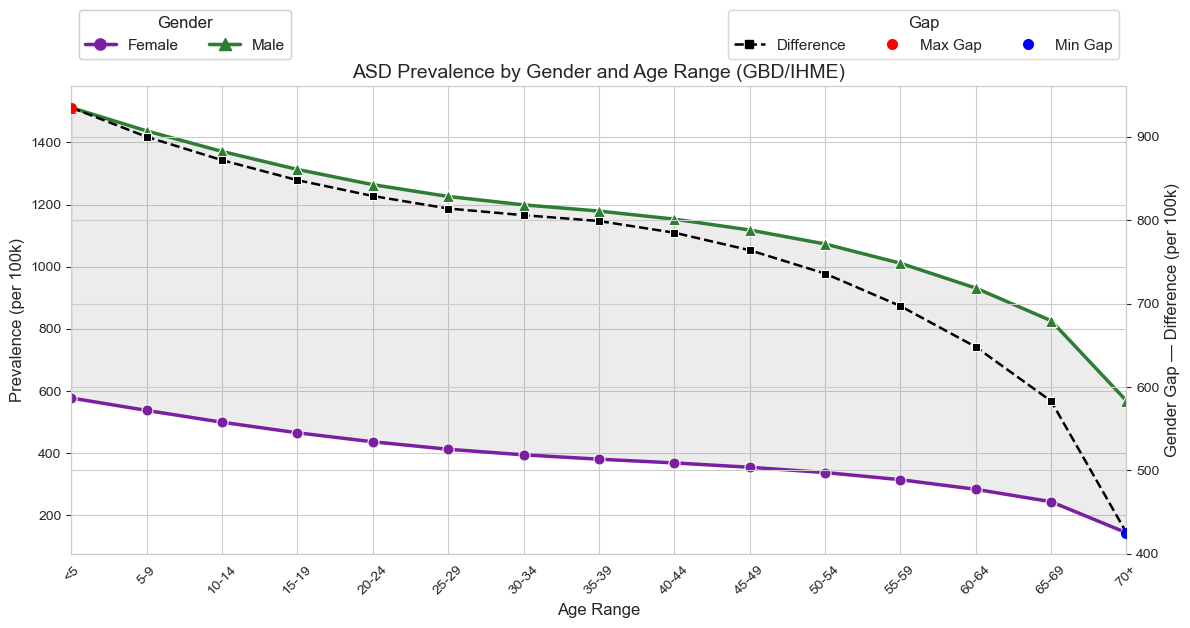

In [77]:
# Visualize ASD prevalence by gender across age ranges and highlight the absolute gender gap

from matplotlib.lines import Line2D

sns.set_style("whitegrid")

# Define consistent typography and styling
title_size = 14
label_size = 12
tick_size = 10
legend_size = 11
legend_title_size = 12

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot prevalence lines for each gender
sns.lineplot(
    data=df_gender_age_pivot,
    x="age_range",
    y="female_prevalence",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#7B1FA2",
    ax=ax1
)

sns.lineplot(
    data=df_gender_age_pivot,
    x="age_range",
    y="male_prevalence",
    marker="^",
    markersize=8,
    linewidth=2.5,
    color="#2E7D32",
    ax=ax1
)

# Fill the space between prevalence lines to reinforce the visual gap
ax1.fill_between(
    df_gender_age_pivot["age_range"].astype(str),
    df_gender_age_pivot["female_prevalence"],
    df_gender_age_pivot["male_prevalence"],
    color="gray",
    alpha=0.15
)

# Configure primary axis for prevalence
ax1.set_title("ASD Prevalence by Gender and Age Range (GBD/IHME)", fontsize=title_size)
ax1.set_xlabel("Age Range", fontsize=label_size)
ax1.set_ylabel("Prevalence (per 100k)", fontsize=label_size)
ax1.tick_params(axis="x", rotation=45, labelsize=tick_size)
ax1.tick_params(axis="y", labelsize=tick_size)
ax1.set_xlim(0, len(df_gender_age_pivot) - 1)

# Plot the absolute gender gap on a secondary axis
ax2 = ax1.twinx()

sns.lineplot(
    data=df_gender_age_pivot,
    x="age_range",
    y="difference",
    linestyle="--",
    linewidth=1.8,
    color="black",
    marker="s",
    markersize=6,
    ax=ax2
)

# Highlight critical points in the gap series
max_idx = df_gender_age_pivot["difference"].idxmax()
min_idx = df_gender_age_pivot["difference"].idxmin()

ax2.scatter(
    df_gender_age_pivot.loc[max_idx, "age_range"],
    df_gender_age_pivot.loc[max_idx, "difference"],
    color="red",
    s=50,
    zorder=5
)

ax2.scatter(
    df_gender_age_pivot.loc[min_idx, "age_range"],
    df_gender_age_pivot.loc[min_idx, "difference"],
    color="blue",
    s=50,
    zorder=5
)

# Configure secondary axis for difference
ax2.set_ylabel("Gender Gap — Difference (per 100k)", fontsize=label_size)
ax2.tick_params(axis="y", labelsize=tick_size)

# Build separate legends for gender and gap without overlapping the plot
gender_handles = [
    Line2D([0], [0], color="#7B1FA2", marker="o", linewidth=2.5, markersize=8, label="Female"),
    Line2D([0], [0], color="#2E7D32", marker="^", linewidth=2.5, markersize=8, label="Male")
]

gap_handles = [
    Line2D([0], [0], color="black", linestyle="--", marker="s", linewidth=1.8, markersize=6, label="Difference"),
    Line2D([0], [0], color="red", marker="o", linestyle="", markersize=7, label="Max Gap"),
    Line2D([0], [0], color="blue", marker="o", linestyle="", markersize=7, label="Min Gap")
]

legend_gender = ax1.legend(
    handles=gender_handles,
    title="Gender",
    fontsize=legend_size,
    title_fontsize=legend_title_size,
    loc="upper left",
    bbox_to_anchor=(0, 1.18),
    ncol=2,
    frameon=True
)

legend_gap = ax2.legend(
    handles=gap_handles,
    title="Gap",
    fontsize=legend_size,
    title_fontsize=legend_title_size,
    loc="upper right",
    bbox_to_anchor=(1, 1.18),
    ncol=3,
    frameon=True
)

ax1.add_artist(legend_gender)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# save figure (high resolution for portfolio / reports)
plt.savefig(FIGURES_DIR / "4_3_1_gender_age.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

This visualization shows the estimated ASD prevalence by gender across different age groups in OECD countries (GBD/IHME, per 100k population).

For both males and females, prevalence decreases progressively with age, with the highest values in the youngest groups and the lowest in 70+. Male prevalence remains consistently higher than female prevalence across all age ranges, resulting in a positive gap throughout.

The *difference* line (secondary axis) represents this absolute gap (Male − Female). It is largest in early ages (<5 years) and decreases steadily with age, reaching its minimum in the 70+ group.

This reduction in the gap does not imply convergence between genders, but rather a decrease in the absolute difference as both prevalences decline.

---

### 4.3.2 Temporal trends (gender × year)

Analyze the evolution of ASD prevalence over time and compare trends between genders.

Focus:
- evaluate how prevalence changes over time by gender
- assess whether the gender gap remains stable or evolves across years

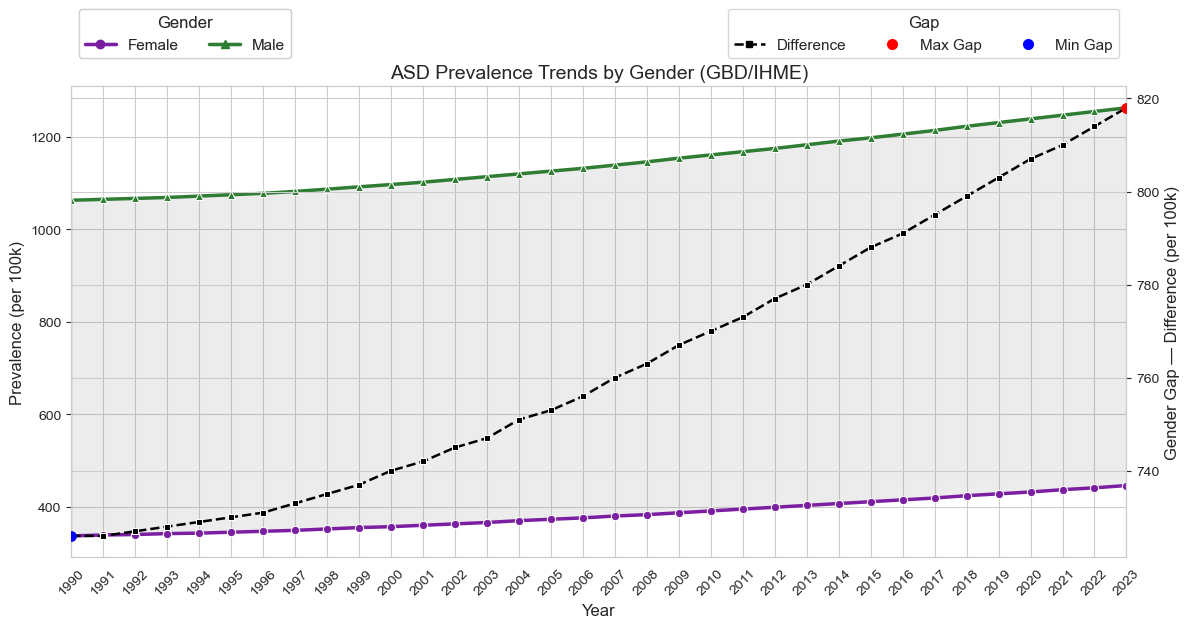

In [78]:
# Visualize ASD prevalence trends over time and highlight the evolution of the absolute gender gap

from matplotlib.lines import Line2D

sns.set_style("whitegrid")

# Define consistent typography and styling
title_size = 14
label_size = 12
tick_size = 10
legend_size = 11
legend_title_size = 12

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot prevalence trends for each gender
sns.lineplot(
    data=df_gender_year_pivot,
    x="year",
    y="female_prevalence",
    marker="o",
    markersize=6,
    linewidth=2.5,
    color="#7B1FA2",
    ax=ax1
)

sns.lineplot(
    data=df_gender_year_pivot,
    x="year",
    y="male_prevalence",
    marker="^",
    markersize=6,
    linewidth=2.5,
    color="#2E7D32",
    ax=ax1
)

# Fill the space between prevalence lines to reinforce the visual gap
ax1.fill_between(
    df_gender_year_pivot["year"],
    df_gender_year_pivot["female_prevalence"],
    df_gender_year_pivot["male_prevalence"],
    color="gray",
    alpha=0.15
)

# Configure primary axis for prevalence
ax1.set_title("ASD Prevalence Trends by Gender (GBD/IHME)", fontsize=title_size)
ax1.set_xlabel("Year", fontsize=label_size)
ax1.set_ylabel("Prevalence (per 100k)", fontsize=label_size)
ax1.set_xticks(df_gender_year_pivot["year"])
ax1.tick_params(axis="x", rotation=45, labelsize=tick_size)
ax1.tick_params(axis="y", labelsize=tick_size)
ax1.set_xlim(df_gender_year_pivot["year"].min(), df_gender_year_pivot["year"].max())

# Plot the absolute gender gap on a secondary axis
ax2 = ax1.twinx()

sns.lineplot(
    data=df_gender_year_pivot,
    x="year",
    y="difference",
    linestyle="--",
    linewidth=1.8,
    color="black",
    marker="s",
    markersize=5,
    ax=ax2
)

# Highlight critical points in the gap series
max_idx = df_gender_year_pivot["difference"].idxmax()
min_idx = df_gender_year_pivot["difference"].idxmin()

ax2.scatter(
    df_gender_year_pivot.loc[max_idx, "year"],
    df_gender_year_pivot.loc[max_idx, "difference"],
    color="red",
    s=45,
    zorder=5
)

ax2.scatter(
    df_gender_year_pivot.loc[min_idx, "year"],
    df_gender_year_pivot.loc[min_idx, "difference"],
    color="blue",
    s=45,
    zorder=5
)

# Configure secondary axis for difference
ax2.set_ylabel("Gender Gap — Difference (per 100k)", fontsize=label_size)
ax2.tick_params(axis="y", labelsize=tick_size)

# Build separate legends for gender and gap without overlapping the plot
gender_handles = [
    Line2D([0], [0], color="#7B1FA2", marker="o", linewidth=2.5, markersize=6, label="Female"),
    Line2D([0], [0], color="#2E7D32", marker="^", linewidth=2.5, markersize=6, label="Male")
]

gap_handles = [
    Line2D([0], [0], color="black", linestyle="--", marker="s", linewidth=1.8, markersize=5, label="Difference"),
    Line2D([0], [0], color="red", marker="o", linestyle="", markersize=7, label="Max Gap"),
    Line2D([0], [0], color="blue", marker="o", linestyle="", markersize=7, label="Min Gap")
]

legend_gender = ax1.legend(
    handles=gender_handles,
    title="Gender",
    fontsize=legend_size,
    title_fontsize=legend_title_size,
    loc="upper left",
    bbox_to_anchor=(0, 1.18),
    ncol=2,
    frameon=True
)

legend_gap = ax2.legend(
    handles=gap_handles,
    title="Gap",
    fontsize=legend_size,
    title_fontsize=legend_title_size,
    loc="upper right",
    bbox_to_anchor=(1, 1.18),
    ncol=3,
    frameon=True
)

ax1.add_artist(legend_gender)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# save figure (high resolution for portfolio / reports)
plt.savefig(FIGURES_DIR / "4_3_2_gender_year.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

This visualization shows the temporal evolution of estimated ASD prevalence for females and males in OECD countries (GBD/IHME, per 100k population).

Both series exhibit an increasing trend over time, with rising prevalence in both males and females. Male prevalence remains consistently higher than female prevalence throughout the entire period, resulting in a positive gap in all years.

The *difference* line (secondary axis) represents this absolute gap (Male − Female). It increases progressively over time, reaching its highest values in the most recent years.

This increase in the gap does not imply a decrease in female prevalence or a relative divergence between genders, but rather that both prevalences are rising and male prevalence is increasing by a greater absolute magnitude, thereby widening the difference in per 100k terms.

---

### 4.3.3 Country comparison (country × gender)

Compare ASD prevalence across OECD countries and identify cross-country differences between genders.

Focus:
- evaluate variation in prevalence across countries
- identify countries with higher or lower prevalence levels

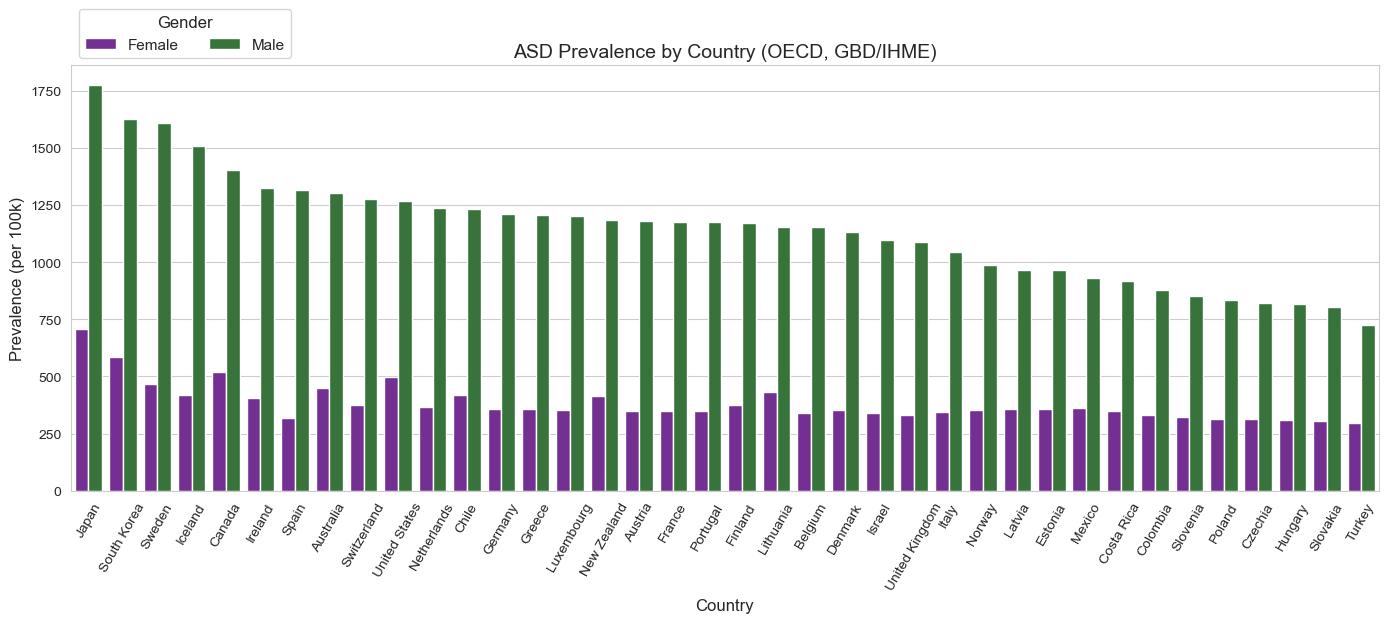

In [79]:
# Compare ASD prevalence by gender across OECD countries using vertical bars

sns.set_style("whitegrid")

# Define consistent typography and styling
title_size = 14
label_size = 12
tick_size = 10
legend_size = 11
legend_title_size = 12

fig, ax = plt.subplots(figsize=(14, 7))

# Sort countries by male prevalence to improve readability of the ranking
df_sorted = df_country_gender_pivot.sort_values("male_prevalence", ascending=False)

# Reshape data for grouped bar chart
df_plot = df_sorted.melt(
    id_vars="country",
    value_vars=["female_prevalence", "male_prevalence"],
    var_name="gender",
    value_name="prevalence"
)

df_plot["gender"] = df_plot["gender"].map({
    "female_prevalence": "Female",
    "male_prevalence": "Male"
})

# Plot grouped vertical bars for both genders
sns.barplot(
    data=df_plot,
    x="country",
    y="prevalence",
    hue="gender",
    palette={"Female": "#7B1FA2", "Male": "#2E7D32"},
    ax=ax
)

# Configure plot appearance
ax.set_title("ASD Prevalence by Country (OECD, GBD/IHME)", fontsize=title_size)
ax.set_xlabel("Country", fontsize=label_size)
ax.set_ylabel("Prevalence (per 100k)", fontsize=label_size)
ax.tick_params(axis="x", rotation=60, labelsize=tick_size)
ax.tick_params(axis="y", labelsize=tick_size)

ax.legend(
    title="Gender",
    fontsize=legend_size,
    title_fontsize=legend_title_size,
    loc="upper left",
    bbox_to_anchor=(0, 1.15),
    ncol=2,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# save figure (high resolution for portfolio / reports)
plt.savefig(FIGURES_DIR / "4_3_3_country_gender.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

This visualization compares the estimated ASD prevalence between females and males for each OECD country (GBD/IHME, per 100k population).

In all countries, male prevalence is higher than female prevalence, indicating a consistently positive absolute gap across the entire cohort.

There is also clear heterogeneity in prevalence levels between countries. Some countries, such as Japan, South Korea, or Sweden, show higher values in both sexes, while others like Turkey, Slovakia, or Hungary display lower levels.

The distance between Female and Male bars varies across countries, indicating that the magnitude of the absolute gap is not uniform internationally.

Overall, the chart allows for a simultaneous comparison of gender differences within each country and the variability in prevalence levels across countries, without implying causality.

---

### 4.3.4 Regional comparison (region × gender)

Compare ASD prevalence across OECD regions and evaluate how gender differences vary at a macro-geographical level.

Focus:
- identify regional patterns in prevalence
- assess whether gender disparities are consistent across regions

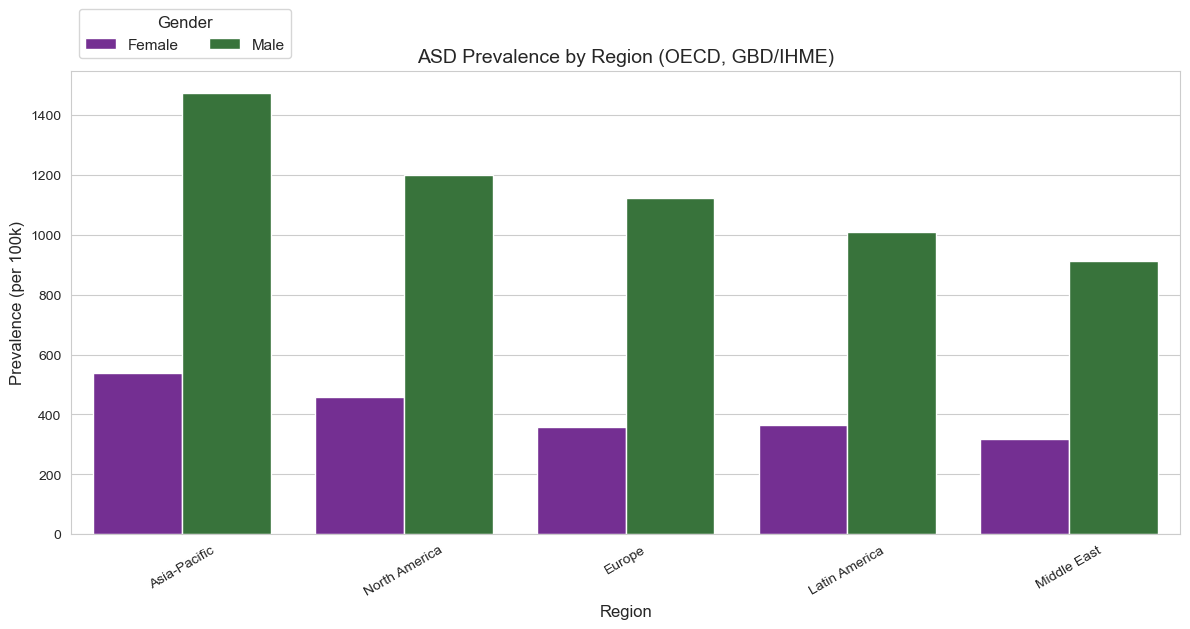

In [80]:
# Compare ASD prevalence by gender across OECD regions using vertical bars

sns.set_style("whitegrid")

# Define consistent typography and styling
title_size = 14
label_size = 12
tick_size = 10
legend_size = 11
legend_title_size = 12

fig, ax = plt.subplots(figsize=(12, 7))

# Sort regions by male prevalence to present a consistent ranking
df_sorted = df_region_gender_pivot.sort_values("male_prevalence", ascending=False)

# Reshape data for grouped bar chart
df_plot = df_sorted.melt(
    id_vars="region",
    value_vars=["female_prevalence", "male_prevalence"],
    var_name="gender",
    value_name="prevalence"
)

df_plot["gender"] = df_plot["gender"].map({
    "female_prevalence": "Female",
    "male_prevalence": "Male"
})

# Plot grouped vertical bars for both genders
sns.barplot(
    data=df_plot,
    x="region",
    y="prevalence",
    hue="gender",
    palette={"Female": "#7B1FA2", "Male": "#2E7D32"},
    ax=ax
)

# Configure plot appearance
ax.set_title("ASD Prevalence by Region (OECD, GBD/IHME)", fontsize=title_size)
ax.set_xlabel("Region", fontsize=label_size)
ax.set_ylabel("Prevalence (per 100k)", fontsize=label_size)
ax.tick_params(axis="x", rotation=30, labelsize=tick_size)
ax.tick_params(axis="y", labelsize=tick_size)

ax.legend(
    title="Gender",
    fontsize=legend_size,
    title_fontsize=legend_title_size,
    loc="upper left",
    bbox_to_anchor=(0, 1.15),
    ncol=2,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# save figure (high resolution for portfolio / reports)
plt.savefig(FIGURES_DIR / "4_3_4_region_gender.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

This visualization compares the estimated ASD prevalence between females and males by region within OECD countries (GBD/IHME, per 100k population).

In all regions, male prevalence is higher than female prevalence, indicating a consistently positive absolute gap across all regional aggregates.

In terms of magnitude, Asia-Pacific shows the highest prevalence levels in both sexes, followed by North America and Europe. In contrast, Latin America and the Middle East display lower prevalence levels.

The distance between Female and Male bars also varies across regions, indicating that the magnitude of the absolute gap is not homogeneous at the regional level.

Overall, the chart highlights both the consistent higher prevalence in males and the geographic variability of the indicator, without implying causal relationships.

---

## 4.3.5 — Overall comparison (Gender & Gap)

This section provides a synthetic view of ASD prevalence differences between genders across the OECD cohort.

It includes two complementary visualizations:

1. **Overall prevalence comparison (Female vs Male)**  
   A line-based visualization comparing the aggregated prevalence levels for both genders, including shaded areas to highlight the difference.

2. **Gap comparison (Absolute vs Relative)**  
   A dual-axis visualization comparing:
   - Absolute gap (Male − Female)
   - Relative gap (Female / Male)

These plots aim to summarize, in a single view, both the magnitude and the proportional relationship of gender differences observed in previous analyses.

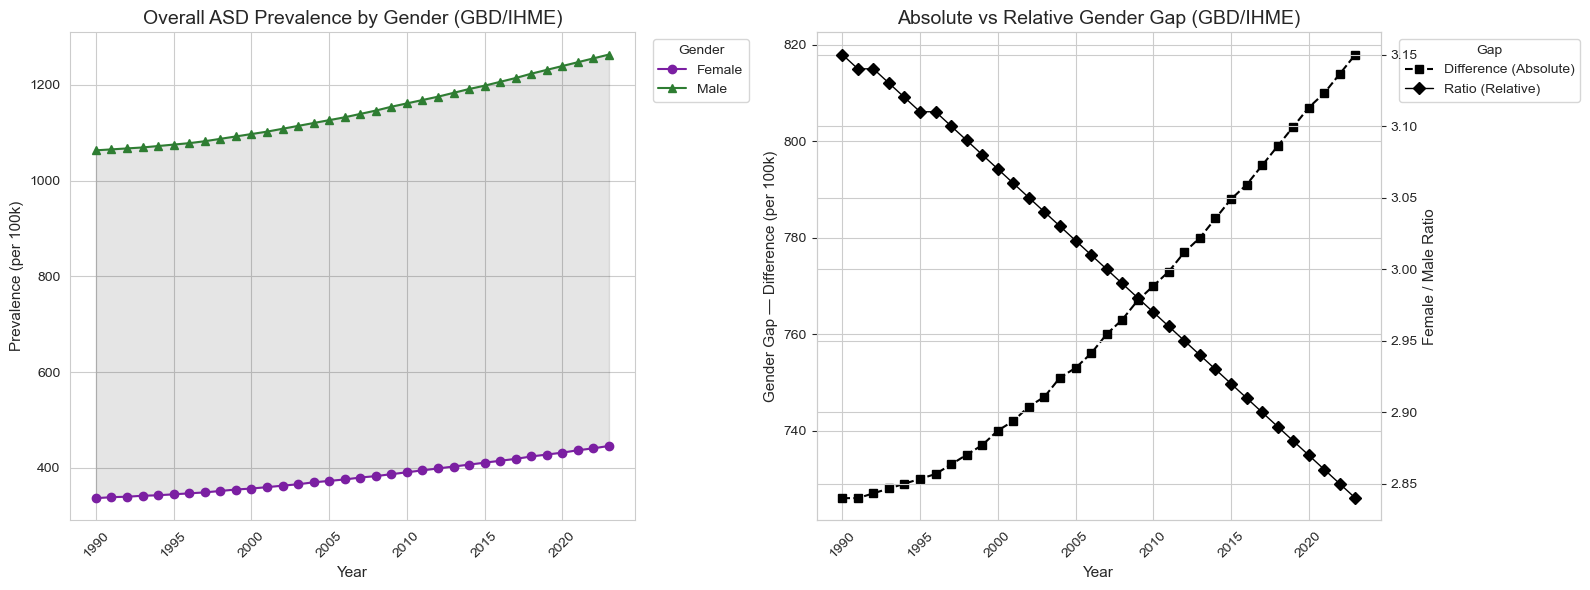

In [81]:
# Overall comparison (Gender & Gap)

# use gender × year dataset

df_overall = df_gender_year_pivot.copy()

# figure with two subplots

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# overall prevalence (female vs male)

ax1 = axes[0]

ax1.plot(
    df_overall["year"],
    df_overall["female_prevalence"],
    color=FEMALE_COLOR,
    marker=MARKER_FEMALE,
    label="Female"
)

ax1.plot(
    df_overall["year"],
    df_overall["male_prevalence"],
    color=MALE_COLOR,
    marker=MARKER_MALE,
    label="Male"
)

ax1.fill_between(
    df_overall["year"],
    df_overall["female_prevalence"],
    df_overall["male_prevalence"],
    color="black",
    alpha=0.10
)

ax1.set_title("Overall ASD Prevalence by Gender (GBD/IHME)", fontsize=TITLE_SIZE)
ax1.set_xlabel("Year", fontsize=LABEL_SIZE)
ax1.set_ylabel("Prevalence (per 100k)", fontsize=LABEL_SIZE)

ax1.tick_params(axis="x", labelsize=TICK_SIZE, rotation=45)
ax1.tick_params(axis="y", labelsize=TICK_SIZE)

ax1.legend(
    title="Gender",
    fontsize=LEGEND_SIZE,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# gap (absolute vs relative)

ax2 = axes[1]
ax2b = ax2.twinx()

ax2.plot(
    df_overall["year"],
    df_overall["difference"],
    color=GAP_COLOR,
    linestyle="--",
    linewidth=1.5,
    marker=MARKER_GAP,
    label="Difference (Absolute)"
)

ax2b.plot(
    df_overall["year"],
    df_overall["ratio"],
    color=GAP_COLOR,
    linestyle="-",
    linewidth=1.0,
    marker=MARKER_RATIO,
    label="Ratio (Relative)"
)

ax2.set_title("Absolute vs Relative Gender Gap (GBD/IHME)", fontsize=TITLE_SIZE)
ax2.set_xlabel("Year", fontsize=LABEL_SIZE)

ax2.set_ylabel("Gender Gap — Difference (per 100k)", fontsize=LABEL_SIZE)
ax2b.set_ylabel("Female / Male Ratio", fontsize=LABEL_SIZE)

ax2.tick_params(axis="x", labelsize=TICK_SIZE, rotation=45)
ax2.tick_params(axis="y", labelsize=TICK_SIZE)
ax2b.tick_params(axis="y", labelsize=TICK_SIZE)

lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2b.get_legend_handles_labels()

ax2.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    title="Gap",
    fontsize=LEGEND_SIZE,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# save figure (high resolution for portfolio / reports)
plt.savefig(FIGURES_DIR / "4_3_5_overall.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

This visualization summarizes the overall evolution of ASD prevalence by gender and the relationship between them across OECD countries (GBD/IHME, per 100k population).

In the first plot, both female and male prevalence show a steady increasing trend over time. Male prevalence remains consistently higher than female prevalence in all years, resulting in a positive absolute gap throughout the period. The shaded area highlights that this separation between both series progressively widens over time.

The second plot analyzes this gap from two complementary perspectives. The **difference** line (left axis) shows that the absolute gap between males and females increases continuously, reaching its highest values in the most recent years. This indicates a growing absolute distance in prevalence per 100k.

In contrast, the **ratio** line (right axis) represents the relative relationship between both prevalences (Female / Male) and shows a decreasing trend. This indicates that, proportionally, female prevalence represents a smaller share relative to male prevalence over time.

This pattern is also consistent from a compositional perspective: although not explicitly visualized, the female percentage of total prevalence decreases over time, reflecting a gradual shift in the overall distribution towards a higher male share.

Both metrics must be interpreted together: while the absolute gap increases, the ratio decreases, reflecting that male prevalence is growing faster than female prevalence in both absolute and relative terms.

---

## 4.4 — Key Insights (Gender Differences in ASD Prevalence)

This section synthesizes the main findings from the previous analyses, integrating results across age, time, and geography.

Across all dimensions, ASD prevalence is consistently higher in males than in females, resulting in a persistent positive gender gap.

From an age perspective, prevalence decreases with age in both sexes, and the absolute gap narrows in older groups. This indicates that the difference between sexes is more pronounced in early developmental stages.

From a temporal perspective, prevalence increases over time for both sexes. However, the absolute gap also widens, while the relative ratio decreases. This reflects a faster growth in male prevalence, both in absolute and proportional terms.

From a geographic perspective, the male–female difference is consistent across all OECD countries and regions, although the magnitude of prevalence varies significantly between them. This suggests that the gender gap is a stable pattern, while overall prevalence levels are context-dependent.

Taken together, these results indicate that gender differences in ASD prevalence are robust across dimensions but evolve differently depending on the analytical perspective. The widening absolute gap over time, combined with a declining relative ratio, highlights a structural divergence that is not captured by a single metric alone.